<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Building_Agentic_Document_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Agentic Document Understanding
A combination of OCR, Layout Detection, and VLM
1.   PaddleOCR: Text extraction and Layout LM for reading order
2.   Layout detection: To detect tables, chart and regions
3.   Agentic processing: Langchain agent with two special tools
*   Analyze chart: A VLM-based chart figure analysis
*   VLM-table: A VLM-table extraction

In [ ]:
import torch
torch.cuda.is_available()

In [12]:
import os
# Control the logs
# os.environ["GLOG_minloglevel"] = "2" # 0=INFO, 1=WARNING, 2=ERROR, 3=FATAL
from dotenv import load_dotenv

In [3]:
_ = load_dotenv(override=True)

In [4]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass # Decorator for creating clean data structures
from typing import List, Dict, Any

In [ ]:
# Install all functionalities, such as document parsing, document understanding,
# document translation, and key information extraction
!pip install "paddleocr[all]"

In [ ]:
# You need to install paddlepaddle superatedly appart from paddlleocr
# or you could just !pip install "paddleocr[all]@git+https://github.com/PaddlePaddle/PaddleOCR.git"
# Make sure the paddle version matches to paddleOCR version
!pip install paddlepaddle==3.2.0

## 1. Text extraction with PaddleOCR + LayoutLM Ordering

In [11]:
from paddleocr import PaddleOCR

In [ ]:
# Initialize PaddleOCR
ocr = PaddleOCR(lang='en')

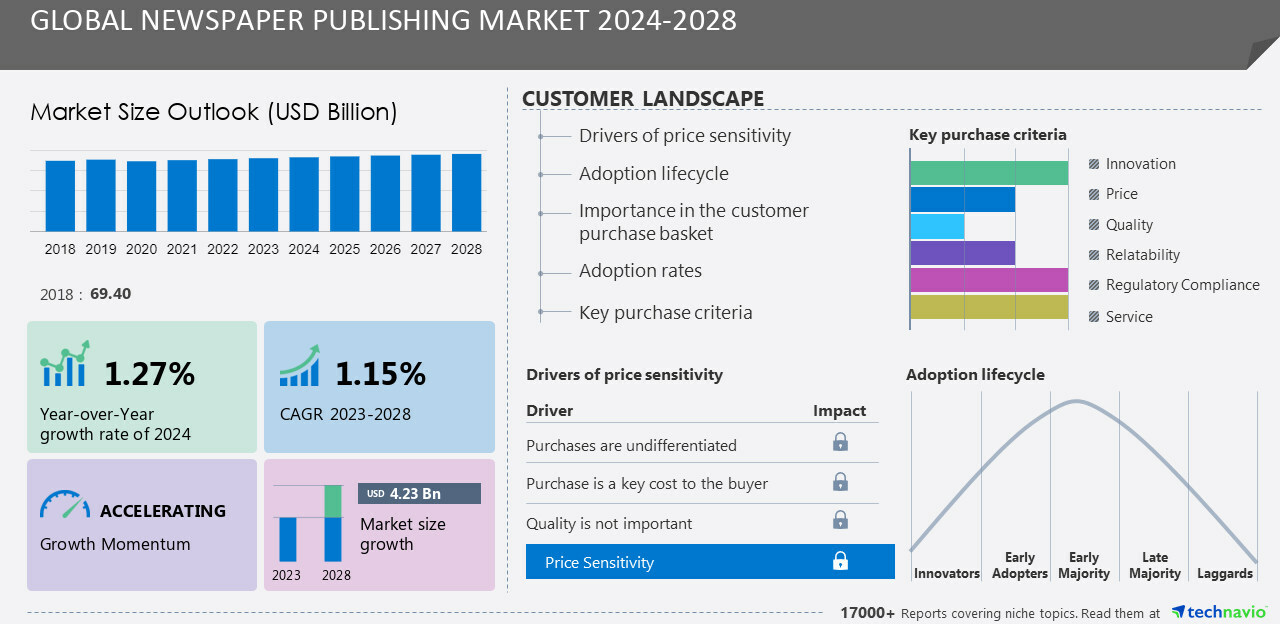

In [16]:
# Load image
image_path = 'Technavio_Infographic.jpg'
display(Image.open(image_path))

In [17]:
# Run OCR
result = ocr.predict(image_path)

In [18]:
page = result[0]
texts = page['rec_texts'] # recognized text string
scores = page['rec_scores'] # confidence scores
boxes = page['rec_polys'] # bounding box coordinates

print(f"Extracted {len(texts)} text regions")
print("\nFirst 10 regions:")
for text, score, box in list(zip(texts, scores, boxes))[:10]:
  coords = box.astype(int).tolist()
  print(f'- {text:40} | {score:.3f} | {coords}')


Extracted 49 text regions

First 10 regions:
- SHING MARKET 2024-2028                   | 0.976 | [[388, 0], [756, 0], [756, 20], [388, 20]]
- Market Size Outlook (UsD Billion)        | 0.979 | [[0, 87], [403, 90], [403, 117], [0, 114]]
- CUSTOMER LANDSCAPE                       | 0.982 | [[531, 80], [785, 81], [785, 101], [531, 100]]
- Drivers of price sensitivity             | 1.000 | [[586, 116], [814, 119], [814, 142], [586, 139]]
- Key purchase criteria                    | 1.000 | [[931, 121], [1102, 119], [1102, 139], [931, 141]]
- Adoption lifecycle                       | 1.000 | [[583, 157], [747, 157], [747, 180], [583, 180]]
- %Innovation                              | 0.976 | [[1121, 149], [1222, 149], [1222, 169], [1121, 169]]
- Price                                    | 1.000 | [[1122, 177], [1185, 177], [1185, 202], [1122, 202]]
- Importance in the customer               | 1.000 | [[582, 193], [835, 196], [835, 222], [582, 219]]
- purchase basket                        

### Visualizing OCR Bounding Boxes

In [ ]:
processed_img = page['doc_preprocessor_res']['output_img']
img_plot = processed_img.copy()
show_text = False
for text, box in zip(texts, boxes):
  pts = np.array(box, dtype=int)
  cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
  x, y = pts[0]
  if show_text:
    cv2.putText(img_plot, text, (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

  plt.figure(figsize=(8, 10))
  plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.title("Aligned Bounding Boxes (processed Image)")
  plt.show()

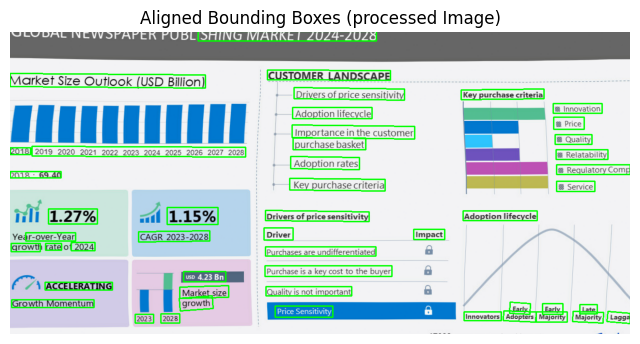

### Structuring OCR Results with a Dataclass
A clean type structure for each text region and convert 4 polygon format to a simple `[[x1, y1], [x2, y2]]`

In [20]:
# Store OCR results in a structured format
@dataclass
class OCRRegion:
  text: str
  bbox: list #[[x1, y1], [x2, y2]]
  confidence: float
  @property
  def bbox_xyxy(self):
    """Return bbox as [x1, y1, x2, y2] format."""
    x_coords = [p[0] for p in self.bbox]
    y_coords = [p[1] for p in self.bbox]
    return [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]

ocr_regions: List[OCRRegion] = []
for text, score, box in zip(texts, scores, boxes):
  ocr_regions.append(OCRRegion(
      text=text,
      bbox=box.astype(int).tolist(),
      confidence=score
  ))

  print(f'Stored {len(ocr_regions)} OCR regions')


Stored 1 OCR regions
Stored 2 OCR regions
Stored 3 OCR regions
Stored 4 OCR regions
Stored 5 OCR regions
Stored 6 OCR regions
Stored 7 OCR regions
Stored 8 OCR regions
Stored 9 OCR regions
Stored 10 OCR regions
Stored 11 OCR regions
Stored 12 OCR regions
Stored 13 OCR regions
Stored 14 OCR regions
Stored 15 OCR regions
Stored 16 OCR regions
Stored 17 OCR regions
Stored 18 OCR regions
Stored 19 OCR regions
Stored 20 OCR regions
Stored 21 OCR regions
Stored 22 OCR regions
Stored 23 OCR regions
Stored 24 OCR regions
Stored 25 OCR regions
Stored 26 OCR regions
Stored 27 OCR regions
Stored 28 OCR regions
Stored 29 OCR regions
Stored 30 OCR regions
Stored 31 OCR regions
Stored 32 OCR regions
Stored 33 OCR regions
Stored 34 OCR regions
Stored 35 OCR regions
Stored 36 OCR regions
Stored 37 OCR regions
Stored 38 OCR regions
Stored 39 OCR regions
Stored 40 OCR regions
Stored 41 OCR regions
Stored 42 OCR regions
Stored 43 OCR regions
Stored 44 OCR regions
Stored 45 OCR regions
Stored 46 OCR regio

### LayoutLM Reading Order

In [ ]:
# Setup the layoutreader project or just use the
# original https://github.com/microsoft/unilm/tree/master/layoutreader
# You might also import your layoutreader from your local machine if you want
!git clone https://github.com/ppaanngggg/layoutreader.git
!pip install -r layoutreader/requirements.txt
import sys
sys.path.append("/layoutreader")

In [40]:
from transformers import LayoutLMv3ForTokenClassification
from v3.helpers import prepare_inputs, boxes2inputs, parse_logits

In [ ]:
# load LayoutReader model
print("loading pretrain LayoutReader model from huggingface...")
model_slug='hantian/layoutreader' #https://huggingface.co/hantian/layoutreader
layout_model = LayoutLMv3ForTokenClassification.from_pretrained(model_slug)
print('model loadded successfully!')

## Reading order detection function

In [44]:
def get_reading_order(ocr_regions):
  """
  Use LayoutReader to determine reading order of OCR regiions.
  Returns list of reading order positions fro each region index
  """
  # 1. Calculate image dimentions from bounding boxes(with padding)
  max_x = max_y = 0
  for region in ocr_regions:
    x1, y1, x2, y2 = region.bbox_xyxy
    max_x = max(max_x, x2)
    max_y = max(max_y, y2)

  image_width = max_x * 1.1 # add 10% padding
  image_height = max_y * 1.1

  # 2. Conver bboxes to LayoutReader format (normalized to 0-1000)
  boxes = []
  for region in ocr_regions:
    x1, y1, x2, y2 = region.bbox_xyxy
    # Normalize to 0-1000 range
    left = int((x1/image_width)*1000)
    top = int((y1/image_height)*1000)
    right = int((x2/image_width)*1000)
    bottom = int((y2/image_height)*1000)
    boxes.append([left, top, right, bottom])

  # 3. Prepare inputs
  inputs = boxes2inputs(boxes)
  inputs = prepare_inputs(inputs, layout_model)
  # 4. Run inference
  logits = layout_model(**inputs).logits.cpu().squeeze(0)
  # 5. Parse the model's outputs to get reading order
  reading_order = parse_logits(logits, len(boxes))

  return reading_order

In [48]:
# Get reading order
reading_order = get_reading_order(ocr_regions)
print(f'Reading order determined for {len(reading_order)} regions')
print(f'First 20 positions: {reading_order[:20]}')

Reading order determined for 49 regions
First 20 positions: [0, 1, 11, 12, 16, 19, 20, 25, 27, 28, 29, 2, 3, 5, 8, 4, 6, 7, 9, 10]


## Visualize the ther reading order

In [54]:
import matplotlib.patches as pathches
def visualize_reading_order(ocr_regions, image_array, reading_order, title="Reading order"):
  """
  Visualize OCR regions with their reading order numbers using matplotlib.
  """
  fig, ax = plt.subplots(1, figsize=(10, 14))
  ax.imshow(cv2.cvtColor(image_array, cv2.COLOR_RGB2BGR))

  # Create order mapping: index -> reading order position
  order_map = {i:order for i, order in enumerate(reading_order)}

  for i, region in enumerate(ocr_regions):
    bbox = region.bbox
    if bbox and len(bbox) >=4:
      # Draw polygon
      ax.add_patch(pathches.Polygon(bbox, linewidth=2,
                                   edgecolor='blue',
                                   facecolor='none', alpha=0.7))
      # Add reading order number at center
      xs = [p[0] for p in bbox]
      ys = [p[1] for p in bbox]
      ax.text(sum(xs)/len(xs), sum(ys)/len(ys),
              str(order_map.get(i, i)),
              fontsize=13, color='red',
              ha='center',
              va='center', fontweight='bold')
  ax.set_title(title, fontsize=14)
  ax.axis('off')
  plt.tight_layout()
  plt.show()



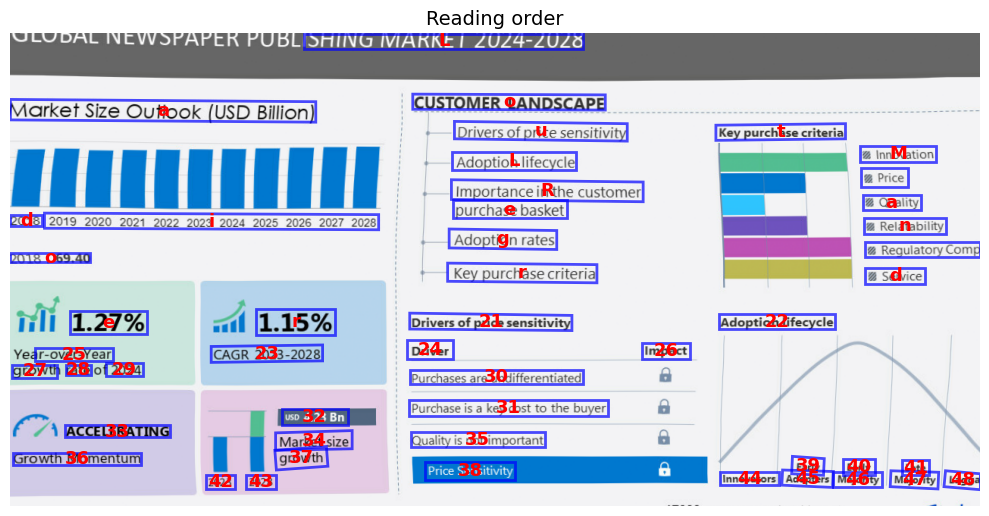

In [55]:
visualize_reading_order(ocr_regions, processed_img, reading_order='LaoutLM Reading order')